
# 🧭 00 – Panorama des bibliothèques de visualisation Python

## 🎯 Objectif
Découvrir les principales bibliothèques de visualisation **autres que Matplotlib** :  
👉 ce qu’elles apportent,  
👉 à qui elles s’adressent,  
👉 et à quoi ressemble un exemple simple.



## 1️⃣ Seaborn — la bibliothèque statistique élégante

### 🔍 Rôle
Seaborn est construite sur Matplotlib et Pandas.  
Elle simplifie énormément la création de **graphes statistiques** : distributions, corrélations, régressions, etc.  
C’est la bibliothèque idéale pour les **data scientists** et **analystes** qui veulent des graphiques clairs, beaux et lisibles, sans écrire 20 lignes de code.

### 💪 Points forts
- Esthétique par défaut (palettes de couleurs harmonieuses)  
- Intégration fluide avec Pandas  
- Graphiques avancés : boxplot, violinplot, pairplot, heatmap…

### ⚠️ Limites
- Moins de personnalisation fine que Matplotlib  
- Centrée sur les DataFrames bien structurés  

### 💻 Exemple


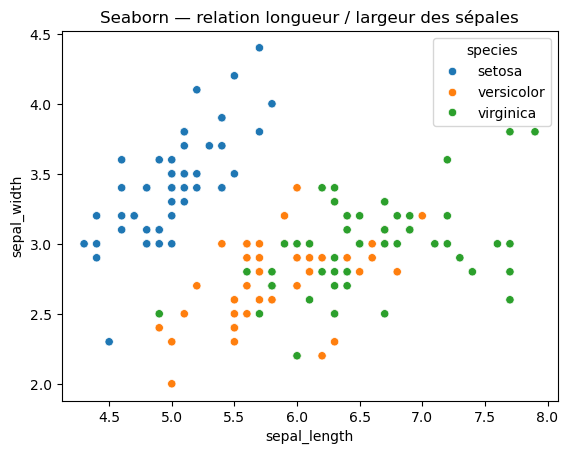

In [4]:

import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")

sns.scatterplot(x="sepal_length", y="sepal_width",
                hue="species", data=iris)
plt.title("Seaborn — relation longueur / largeur des sépales")
plt.show()



### 🧠 À retenir
> “Seaborn, c’est Matplotlib… mais joli, rapide et statistique.”



## 2️⃣ Plotly — la visualisation interactive web

### 🔍 Rôle
Plotly permet de créer des **graphiques interactifs** : zoom, hover, clics, sliders…  
C’est la référence pour les **dashboards**, les présentations web ou les rapports dynamiques.  
Utilisable avec `plotly.express` (haut niveau) ou `graph_objects` (bas niveau).

### 💪 Points forts
- Interactivité native (zoom, survol, export)  
- Compatible avec Jupyter et le web  
- Très large panel de graphiques (2D, 3D, cartes, séries temporelles)

### ⚠️ Limites
- Plus “lourd” à charger  
- Moins pratique pour des scripts hors-web  

### 💻 Exemple


     sepal_length  sepal_width  petal_length  petal_width    species  \
0             5.1          3.5           1.4          0.2     setosa   
1             4.9          3.0           1.4          0.2     setosa   
2             4.7          3.2           1.3          0.2     setosa   
3             4.6          3.1           1.5          0.2     setosa   
4             5.0          3.6           1.4          0.2     setosa   
..            ...          ...           ...          ...        ...   
145           6.7          3.0           5.2          2.3  virginica   
146           6.3          2.5           5.0          1.9  virginica   
147           6.5          3.0           5.2          2.0  virginica   
148           6.2          3.4           5.4          2.3  virginica   
149           5.9          3.0           5.1          1.8  virginica   

     species_id  
0             1  
1             1  
2             1  
3             1  
4             1  
..          ...  
145      

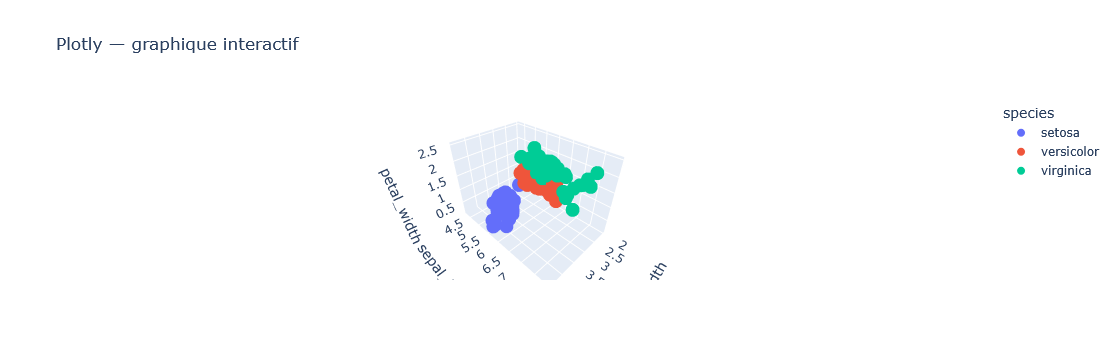

In [8]:

import plotly.express as px

df = px.data.iris()
print(df)
fig = px.scatter_3d(df, x="sepal_width", y="sepal_length",z="petal_width",
                 color="species", title="Plotly — graphique interactif")
fig.show()



### 🧠 À retenir
> “Plotly, c’est la magie du clic et du zoom sans JavaScript.”



## 3️⃣ Folium — la cartographie interactive

### 🔍 Rôle
Folium est un **wrapper Python de Leaflet.js**, la bibliothèque JavaScript la plus populaire pour les cartes interactives.  
Elle permet d’intégrer des **cartes dynamiques** (OpenStreetMap, satellite…) dans vos notebooks ou sites.

### 💪 Points forts
- Très simple à prendre en main  
- Cartes interactives avec zoom et marqueurs  
- Exporte directement en HTML  

### ⚠️ Limites
- Peu adapté aux gros volumes (big data géo)  
- Nécessite une connexion Internet pour les tuiles  

### 💻 Exemple


In [1]:

import folium 

m = folium.Map(location=[48.8566, 2.3522], zoom_start=6)
folium.Marker([48.8566, 2.3522], popup="Paris").add_to(m)
m


In [2]:
import folium
from folium import plugins
import pandas as pd
import numpy as np

# ---- Données fictives ----
np.random.seed(0)
data = pd.DataFrame({
    "ville": ["Paris", "Lyon", "Marseille", "Toulouse", "Bordeaux", "Lille"],
    "lat": [48.8566, 45.7640, 43.2965, 43.6045, 44.8378, 50.6292],
    "lon": [2.3522, 4.8357, 5.3698, 1.4442, -0.5792, 3.0573],
    "pollution": np.random.randint(20, 100, 6),
    "population": [2.1, 0.5, 0.9, 0.5, 0.25, 0.23]
})

# ---- Base Map ----
m = folium.Map(location=[46.5, 2.5], zoom_start=6, tiles="CartoDB positron", control_scale=True)

# ---- 1. Couches de base ----
folium.TileLayer(
    "Stamen Terrain",
    attr="Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap, under ODbL."
).add_to(m)

folium.TileLayer(
    "CartoDB dark_matter",
    attr="Map tiles by CartoDB, under CC BY 3.0. Data by OpenStreetMap."
).add_to(m)

# ---- 2. Points avec info-bulle dynamique ----
for _, row in data.iterrows():
    html = f"""
    <h4>{row['ville']}</h4>
    <b>Population :</b> {row['population']} M<br>
    <b>Pollution :</b> {row['pollution']} µg/m³<br>
    <progress value="{row['pollution']}" max="100"></progress>
    """
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=10,
        color="crimson" if row["pollution"] > 60 else "orange" if row["pollution"] > 40 else "green",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(html, max_width=250),
        tooltip=row["ville"]
    ).add_to(m)

# ---- 3. Heatmap ----
heat_data = [[row["lat"], row["lon"], row["pollution"]] for _, row in data.iterrows()]
plugins.HeatMap(heat_data, radius=40).add_to(m)

# ---- 4. Trajet fictif ----
trajet = [
    [48.8566, 2.3522],  # Paris
    [47.2184, -1.5536],  # Nantes
    [44.8378, -0.5792],  # Bordeaux
]
folium.PolyLine(trajet, color="blue", weight=3, opacity=0.7, tooltip="Trajet livraison").add_to(m)

# ---- 5. Couches activables ----
folium.LayerControl().add_to(m)

# ---- 6. Mini-map ----
plugins.MiniMap(toggle_display=True).add_to(m)

# ---- 7. Bouton de localisation utilisateur ----
plugins.LocateControl(auto_start=False).add_to(m)

# ---- 8. Mode plein écran ----
plugins.Fullscreen(position="topright").add_to(m)

m



### 🧠 À retenir
> “Folium, c’est la porte d’entrée la plus simple vers la cartographie interactive.”



## 4️⃣ Datashader — la visualisation Big Data

### 🔍 Rôle
Datashader est conçu pour afficher **des millions voire milliards de points** sans ralentir.  
Il calcule un rendu pixelisé plutôt que de tracer chaque point individuellement.  
Parfait pour la **visualisation scientifique** ou **géospatiale massive**.

### 💪 Points forts
- Ultra-rapide même sur d’énormes volumes  
- Compatible avec Pandas, Dask, cuDF (GPU)  
- Idéal pour les heatmaps, densités et cartes de points  

### ⚠️ Limites
- Non interactif seul (souvent couplé à Bokeh ou Holoviews)  
- Un peu technique à paramétrer  

### 💻 Exemple


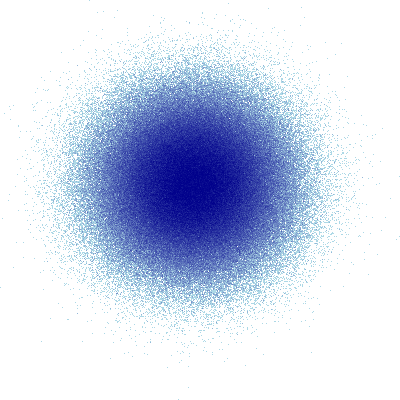

In [1]:

import datashader as ds, datashader.transfer_functions as tf
import pandas as pd, numpy as np

n = 500000
df = pd.DataFrame({'x': np.random.randn(n), 'y': np.random.randn(n)})

canvas = ds.Canvas(plot_width=400, plot_height=400)
agg = canvas.points(df, 'x', 'y')
tf.shade(agg, cmap=["lightblue", "darkblue"])



### 🧠 À retenir
> “Datashader, c’est Matplotlib sous stéroïdes — conçu pour le Big Data.”



## 5️⃣ (Bonus) Altair — la syntaxe déclarative

### 🔍 Rôle
Altair repose sur Vega-Lite, un langage JSON pour la visualisation.  
Ici, on **décrit ce qu’on veut afficher** au lieu de coder chaque étape.  
C’est parfait pour l’enseignement ou le prototypage rapide.

### 💪 Points forts
- Syntaxe ultra lisible (“x encode ça, y encode ça…”)  
- Très adapté à la data exploration  
- Intégré à Jupyter  

### ⚠️ Limites
- Peu d’options 3D / interactives  
- Pas conçu pour les très gros jeux de données  

### 💻 Exemple


In [4]:

import altair as alt
import pandas as pd

df = pd.DataFrame({'x':[1,2,3,4,5], 'y':[6,7,8,5,3]})
alt.Chart(df).mark_line(point=True).encode(x='x', y='y').properties(title="Altair — syntaxe déclarative")


alt.Chart(...)


### 🧠 À retenir
> “Altair, c’est la poésie de la data viz : simple, lisible, expressif.”



## 🧩 Tableau comparatif

| Librairie | Type | Points forts | Idéal pour… |
|------------|------|---------------|--------------|
| **Seaborn** | Statistique | Joli, simple, intégré à Pandas | Analyses rapides et rapport pro |
| **Plotly** | Web / interactif | Zoom, hover, 3D | Dashboards et data storytelling |
| **Folium** | Cartographie | Simplicité, cartes réelles | Localisation, géodonnées |
| **Datashader** | Big Data | Vitesse, performance | Millions de points |
| **Altair** | Déclaratif | Lisibilité, prototypage | Enseignement, exploration |


# bokeh

### Visualisation interactives et dynamiques en Python

In [3]:
from bokeh.plotting import figure, show 
from bokeh.io import output_notebook
#pour le voir la page web dans jupyter
output_notebook()

x = [1, 2, 3, 4, 5] 
y = [6, 7, 2, 4, 5] 
p = figure(title="Exemple Bokeh", x_axis_label="X", y_axis_label="Y") 
p.line(x, y, legend_label="Courbe", line_width=2) 
show(p)

Loading BokehJS ...

In [1]:
import pythreejs as p3 
sphere = p3.Mesh( geometry=p3.SphereGeometry(radius=1, widthSegments=32, heightSegments=16), material=p3.MeshLambertMaterial(color='red'), position=[0, 0, 0] ) 
c = p3.PerspectiveCamera(position=[3, 3, 3], lookAt=[0, 0, 0]) 
scene = p3.Scene(children=[sphere, c, p3.AmbientLight(color='#777777')]) 
renderer = p3.Renderer(camera=c, scene=scene,controls=[p3.OrbitControls(controlling=c)]) 
renderer

ModuleNotFoundError: No module named 'pythreejs'